# **MONTE CARLO INTEGRATION**
- Drawing a random variable is important to understand suddenly why the Monte Carlo method has the advantage of being able to break the curse of dimensionality. 
    - The curse of dimensionality refers, for example, to how classical numerical integration scales exponentially with the number of dimensions. To achieve the same level of accuracy in higher dimensions, you need an exponentially increasing number of sample points. However, the Monte Carlo method breaks this curse because its convergence rate depends only on the number of samples, not on the dimensionality of the problem.
     
- In this method we use MC to estimate the value of an integral by alietoratively sampling. 

## **MONTE-CARLO INTEGRAL ERROR ESTIMATE:**
- **THEOREM:** Estimate the error using the Monte Carlo method to calculate an integral, when the function is defined in a d-dimensional space, 
- Let $f: (0, 1) → R$
- 
- d arguments, d dimensions, and d variables.
- The error of the Monte Carlo method is given by:

$$
P\left(\left|\frac{1}{n} \sum_{i=1}^n f(x_i) - \int_{[0, 1]^d} f(x) \, dx \right| \leq \frac{\sigma}{\sqrt{\delta} \sqrt{n}}\right) \geq 1 - \delta
$$

where:
- $f \in C^0 \cap L^2$, which means that $$f$$ is continuous ($C^0$) and its square is integrable ($L^2$).
- $\int_{[0, 1]^d} f(x) \, dx$: True value of the integral over the $d$-dimensional space.
- $\sigma$: Standard deviation of $f(x)$.
- $\delta$: Confidence level.
- $n$: Number of samples.

How likely is it that the error is less than a certain value?

Note that the parameter d doesn't appear in the prob error estimate


# **MONTE CARLO METHOD:**

### Approximation of "P"by drawing
- If ${X_k}$ is a sequence of independent random drawings 

$$
x_k \in \{w_1, w_2, \dots, w_n\}
$$

- Where the event ${x_k} = {w_i}$ occurs with probability $P({w_i})$, that is we assume that the sequence ${x_k}_k\in N$ is such that:
$$
\frac{1}{M} \sum_{k=1}^M \mathbb{1}_{\{x_k = w_i\}} \to P({w_i}) \text{ as } M \to \infty \space \space (2)
$$

- So, the partial sum $S_M(w_i):= \sum_{k=1}^M \mathbb{1}_{\{x_k = w_i\}}$ is a fairly simple, but seemingly inefficient and useless method to approximate $P({w_i})$

- ``Example:``


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class RandomIntegerSequence:
    def __init__(self, seed=3141):
        self.randomGen = np.random.default_rng(seed)
    #define a printer:
    def print_Seq(self, limit=100):
        for _ in range(limit):
            randomInt = self.randomGen.integers(1, 7)
            print(randomInt)

In [3]:
seq = RandomIntegerSequence()
seq.print_Seq()

4
1
5
6
4
2
5
5
4
1
1
6
3
3
3
1
5
1
2
2
6
1
5
2
1
3
2
4
3
5
3
2
2
3
5
3
2
4
5
1
5
3
6
4
3
2
6
3
5
2
5
5
4
2
2
1
1
2
1
6
4
4
3
6
2
1
5
3
5
1
2
2
5
4
3
3
3
2
5
4
2
1
2
1
3
1
5
1
4
4
6
2
4
5
2
1
3
6
4
3


In [4]:
class runningAvgOfIndicator:
    def getRunningAvgOfIndicator(omega, numberOfSamples, seed):
        avgs = []
        rng = np.random.default_rng(seed)

        #Table part
        print("_" * 79)
        print("i\t x[i]\t indctr\t sum\t avg")
        print("_" * 79)

        sum = 0 
        for i in range(numberOfSamples):
            #################################->SIMULATION<-####################################
            drawing = rng.integers(1, 7) #A random number between 1 and 6 (rolling a dice)
            indicator = (drawing == omega) #If the number is 3 then is true, otherwise is false
            sum += indicator # 1 true | 0 false
            avg = (sum)/(i+1) #Trues/#Number of experiments
            avgs.append(avg) 
            #print(#number of ex | the random number | the acum of times the exp occur | the acum avg) 
            print(f"{i+1}\t {drawing}\t {indicator}\t {sum}\t {avg}")
        print()
        return avgs

#Why is it code a Monte Carlo Method?
#1.- Simulation
#2.- Records the number of an experiment occur
#3.- Repeat the experiment a lot of number of times
#4.- It approximates to the real avg 

In [5]:
def graph_running_averages(number_of_points, avg1, avg2, avg3=None): 
    #number of points is a variable that i need to fix later
    x = range(1, number_of_points + 1) #x-axis, the total number of experiments 
    plt.figure(figsize=(10, 6)) #figsize 
    plt.plot(x, avg1, label="averageValues1 (seed=3105)") #plot the avg1 (y-axis the value of avgs of exp1)
    plt.plot(x, avg2, label="averageValues2 (seed=1)")
    if avg3 is not None:
        plt.plot(x, avg3, label="averageValues3 (seed=1632)")
    plt.axhline(1/6, color='black', linestyle='--', label="Limit 1/6") #Plot the real avg
    plt.title("Plot of running average of indicator function (x[i] == ω[j])")
    plt.xlabel("n")
    plt.ylabel("S(n)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
#Example
number_of_points = 1000
average_values1 = runningAvgOfIndicator.getRunningAvgOfIndicator(3, number_of_points, 3105)
average_values2 = runningAvgOfIndicator.getRunningAvgOfIndicator(3, number_of_points, 1)
average_values3 = runningAvgOfIndicator.getRunningAvgOfIndicator(3, number_of_points, 1632)


_______________________________________________________________________________
i	 x[i]	 indctr	 sum	 avg
_______________________________________________________________________________
1	 3	 True	 1	 1.0
2	 4	 False	 1	 0.5
3	 2	 False	 1	 0.3333333333333333
4	 3	 True	 2	 0.5
5	 1	 False	 2	 0.4
6	 6	 False	 2	 0.3333333333333333
7	 2	 False	 2	 0.2857142857142857
8	 2	 False	 2	 0.25
9	 6	 False	 2	 0.2222222222222222
10	 3	 True	 3	 0.3
11	 3	 True	 4	 0.36363636363636365
12	 2	 False	 4	 0.3333333333333333
13	 3	 True	 5	 0.38461538461538464
14	 4	 False	 5	 0.35714285714285715
15	 6	 False	 5	 0.3333333333333333
16	 4	 False	 5	 0.3125
17	 1	 False	 5	 0.29411764705882354
18	 1	 False	 5	 0.2777777777777778
19	 3	 True	 6	 0.3157894736842105
20	 5	 False	 6	 0.3
21	 1	 False	 6	 0.2857142857142857
22	 2	 False	 6	 0.2727272727272727
23	 3	 True	 7	 0.30434782608695654
24	 3	 True	 8	 0.3333333333333333
25	 2	 False	 8	 0.32
26	 3	 True	 9	 0.34615384615384615
27	 5	 False	 9	 0.3

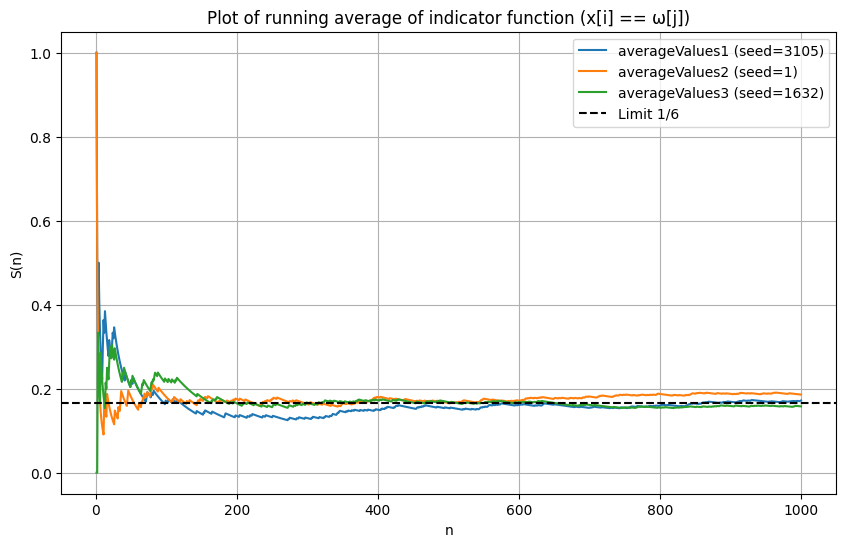

In [7]:
graph_running_averages(number_of_points, average_values1, average_values2, average_values3)

## **IT'S AN INEFFICIENT WAY(IF WE NOW THE PROB):**

- So we could utilize this approximation for the prob $P(w_i)$ in the expression: $Z(w_i) \cdot P({w_i})$
- From (2) we find with  $Z(x_k) \cdot \mathbb{1}_{x_k = w_i} = Z(w_i) \cdot \mathbb{1}_{x_k = w_i}$
    - Where:
        - ${x_k}$ is a sequence of independent random drawings $x_k \in \{w_1, w_2, \dots, w_n\}$
        - The event ${x_k} = {w_i}$ occurs with probability $P({w_i})$
        - **$\mathbb{1}_{x_k = w_i}$ = 1 if $x_k = w_i$ and 0 otherwise$**

$$ 
\frac{1}{M} \sum_{k=1}^M Z(x_k) \cdot \mathbb{1}_{x_k = w_i} = \frac{1}{M} \sum_{k=1}^M Z(w_i) \cdot \mathbb{1}_{x_k = w_i} = Z(w_i) \cdot \frac{1}{M} \sum_{k=1}^M \mathbb{1}_{x_k = w_i} \to Z(w_i) \cdot P({w_i})
$$

- and thus $ \sum_{i=1}^N \cdot {1}_{x_k = w_i} = 1 $
$$ 
\frac{1}{M} \sum_{k=1}^M Z(x_k) \to \frac{1}{M} \sum_{i=1}^N Z(w_i) \cdot P({w_i}) = E^p \cdot (Z) \space for \space M \to \infty
$$

# **MONTE CARLO AAPROXIMATION**

$$ 
\frac{1}{M} \sum_{k=1}^M Z(x_k) \to \sum_{i=1}^N Z(w_i) \cdot P({w_i}) = E^p \cdot (Z) \space for \space M \to \infty
$$


- Since ${x_k}$ is generated according to the probability P, important values $Z(x_k)$ will occur more offen in the sum.
- This may appear inefficient at first. 


- **The expression on the left has two important advantages:**
    - 1.- The number of calculations M requiered to achieve a specific level of approximation is possibly much smaller than N. 
    - 2.- The generation of drawings $x_k$ (which models P) can be done independently from the valuation of Z. The remaining valuation formula is simple: sum up valuations of Z. 
        - In the application of financial derivatives valuation, this allows separating the model (distribution of x) and the financial product (the function Z).
